# Day 29 — Support Vector Machines: Under the Hood, Online SVMs &  Review

- Understand the SVM decision function and prediction rule.
- Understand hard-margin and soft-margin training objectives.
- Connect SVM training to quadratic programming and the dual problem.
- Understand kernelized SVMs, support vectors, and the kernel trick.
- Understand online SVM ideas and scaling limits.
- Know when SVMs are a good choice.
- Review Chapter 5 with exercises and interview questions.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

np.random.seed(42)

## 1. Understanding of SVM

An SVM tries to find a decision boundary with a **large margin** while controlling classification errors.

For a linear classifier:

$$f(x)=w^Tx+b$$

For binary classification:

$$\hat y=\operatorname{sign}(w^Tx+b)$$

The geometric distance from a point to the decision boundary is proportional to:

$$\frac{|w^Tx+b|}{||w||}$$

**Core chain:**

`features → decision function → margin → support vectors → prediction`

## 2. Decision function and predictions

For a trained linear SVM, `decision_function(X)` gives a signed decision score.

- Positive and negative values correspond to different sides of the boundary.
- A larger absolute value generally means the point is farther from the boundary.
- The score is **not automatically a probability**.

In [10]:
iris = load_iris()
X = iris.data[:, (2, 3)]
y = (iris.target == 2).astype(int)  # Virginica vs not Virginica

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1.0, max_iter=10000, random_state=42))
])

linear_svm.fit(X_train, y_train)

scores = linear_svm.decision_function(X_test[:10])
predictions = linear_svm.predict(X_test[:10])

print("Decision scores:", np.round(scores, 3))
print("Predictions:", predictions)
print("Accuracy:", accuracy_score(y_test, linear_svm.predict(X_test)))

Decision scores: [-5.576 -2.372 -5.653 -4.749 -0.61  -1.084  0.035  1.443  1.369  1.628]
Predictions: [0 0 0 0 0 0 1 1 1 1]
Accuracy: 0.9736842105263158


## 3. Training objective: maximum margin + regularization

The simplified hard-margin objective is:

$$\min_w \frac12||w||^2$$

subject to:

$$t^{(i)}(w^Tx^{(i)}+b)\ge1$$

where labels are represented as $t^{(i)}\in\{-1,+1\}$.

Why minimize $||w||$?

The margin is inversely proportional to $||w||$, so minimizing the norm produces a wider margin.

## 4. Soft margin and the `C` hyperparameter

Real datasets are rarely perfectly separable, so SVMs commonly use a **soft margin**.

| `C` | Typical behavior |
|---|---|
| Small | More regularization, wider margin, more tolerance for violations |
| Large | Stronger pressure to fit training examples, narrower margin, possible overfitting |

**Practical rule:** scale features before SVM training.

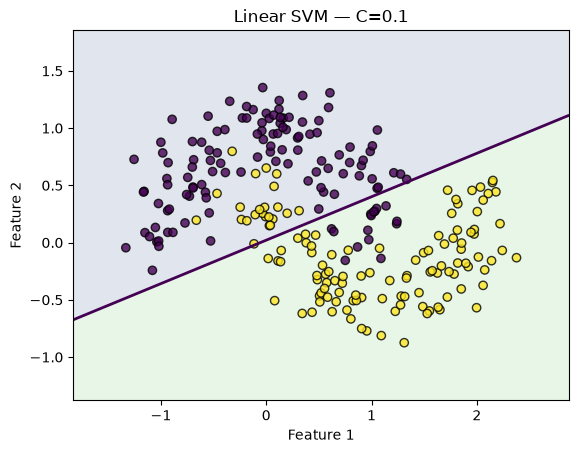

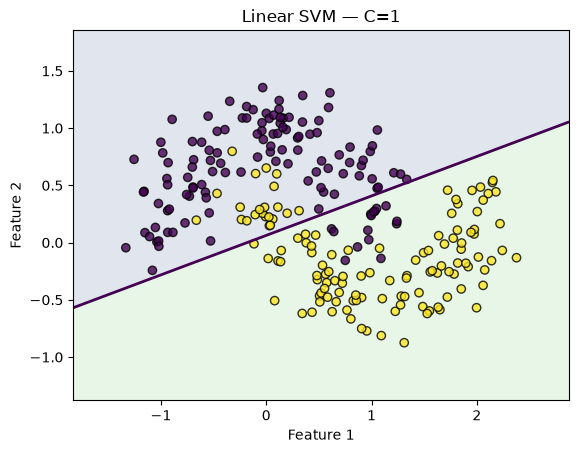

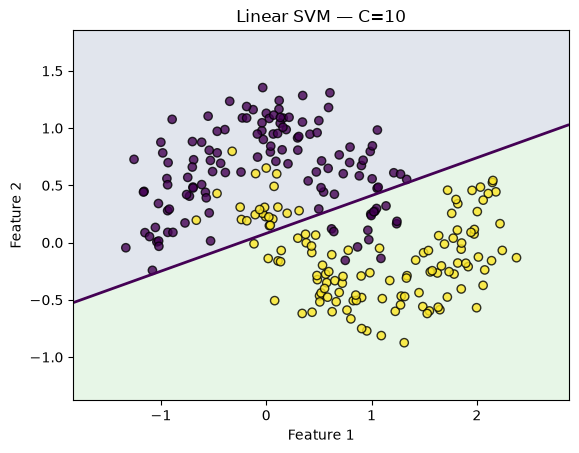

In [11]:
X_moons, y_moons = make_moons(n_samples=250, noise=0.20, random_state=42)

def plot_svm_predictions(model, X, y, title):
    x0s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    x1s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    x0, x1 = np.meshgrid(x0s, x1s)
    grid = np.c_[x0.ravel(), x1.ravel()]

    z = model.decision_function(grid).reshape(x0.shape)
    plt.contourf(x0, x1, z > 0, alpha=0.15)
    plt.contour(x0, x1, z, levels=[0], linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", alpha=0.8)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

for C in [0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C))
    ])
    model.fit(X_moons, y_moons)
    plot_svm_predictions(model, X_moons, y_moons, f"Linear SVM — C={C}")

## 5. Quadratic programming

Classical SVM training can be formulated as a **convex quadratic programming (QP)** problem:

- The objective contains a quadratic term such as $\frac12||w||^2$.
- The constraints are linear.
- In practice, libraries such as scikit-learn handle the optimization.

**Interview takeaway:** SVM training is an optimization problem, and the classical formulation can be expressed as a convex QP.

## 6. The dual problem

The dual formulation introduces Lagrange multipliers $\alpha_i$.

A simplified dual objective is:

$$
\max_\alpha
\sum_i\alpha_i-
\frac12\sum_i\sum_j
\alpha_i\alpha_jt_it_j(x_i^Tx_j)
$$

with constraints including:

$$\alpha_i\ge0$$

and:

$$\sum_i\alpha_it_i=0$$

### Why the dual matters

The dual contains **dot products between training examples**. Those dot products can be replaced with kernel functions.

That is the mathematical doorway to the **kernel trick**.

## 7. Support vectors

Only a subset of training examples is critical to the final boundary. These are the **support vectors**.

With `SVC`:

- `support_` → indices of support vectors
- `support_vectors_` → coordinates
- `n_support_` → number per class

A point far from the boundary generally has little influence, while changing a support vector can change the decision boundary.

In [12]:
rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

rbf_svm.fit(X_moons, y_moons)

svc = rbf_svm.named_steps["svm"]
print("Support vectors per class:", svc.n_support_)
print("Total support vectors:", len(svc.support_))
print("First five support vectors:")
print(svc.support_vectors_[:5])

Support vectors per class: [35 35]
Total support vectors: 70
First five support vectors:
[[ 0.80079054 -0.17581035]
 [-0.46467924  0.85275425]
 [-0.01509953  0.06738052]
 [ 0.63637723 -0.7467004 ]
 [-0.33775226  0.81200496]]


## 8. Kernelized SVMs

Important kernels:

- **Linear:** $K(x,z)=x^Tz$
- **Polynomial:** $K(x,z)=(\gamma x^Tz+r)^d$
- **RBF/Gaussian:** $K(x,z)=e^{-\gamma||x-z||^2}$

### RBF intuition

- Larger `gamma` → more local influence → more complex boundary.
- Smaller `gamma` → broader influence → smoother boundary.
- Larger `C` → stronger pressure to fit training data.

The combination of `C` and `gamma` strongly controls RBF SVM complexity.

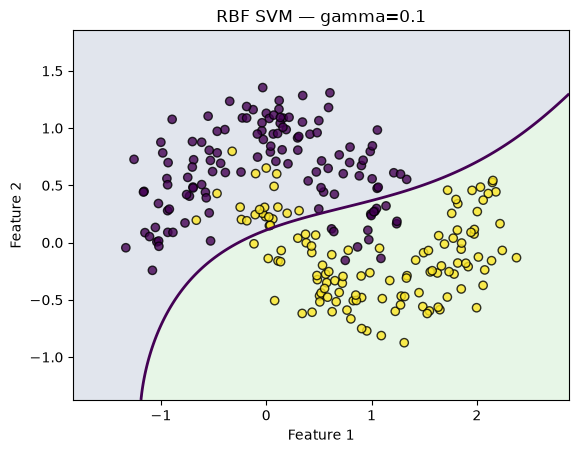

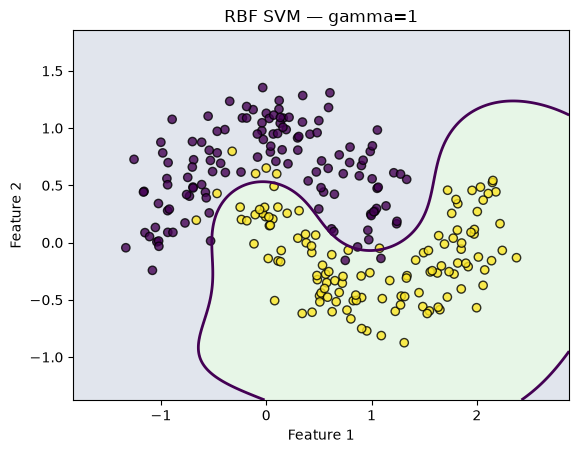

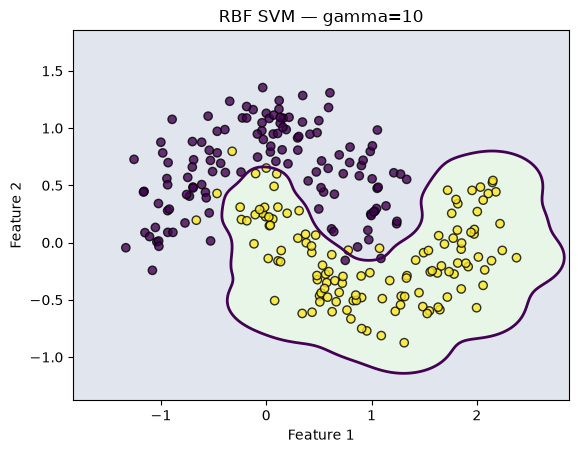

In [13]:
for gamma in [0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma=gamma))
    ])
    model.fit(X_moons, y_moons)
    plot_svm_predictions(model, X_moons, y_moons, f"RBF SVM — gamma={gamma}")

## 9. Polynomial kernel comparison

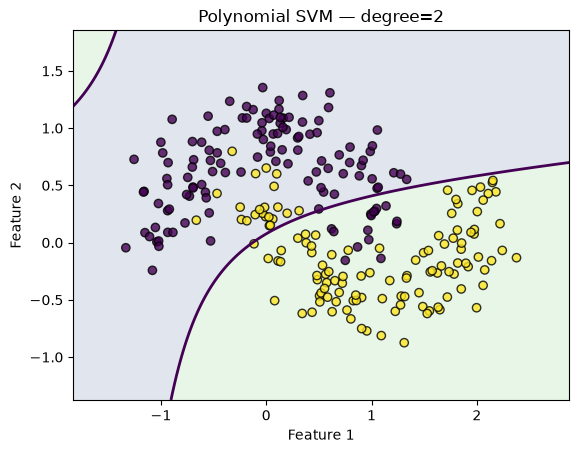

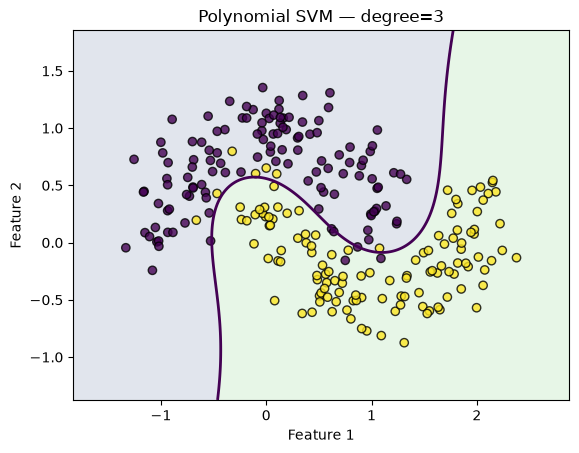

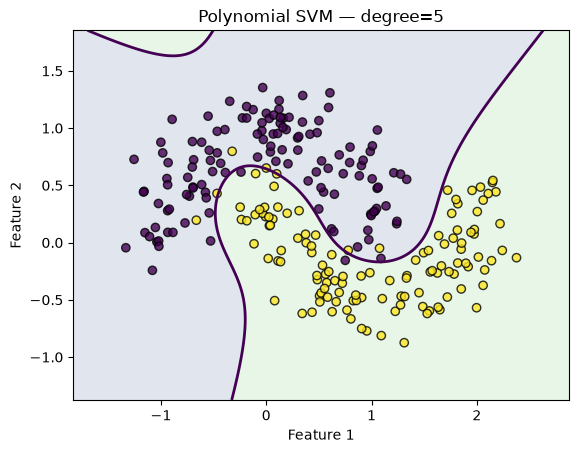

In [14]:
for degree in [2, 3, 5]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=degree, C=5, coef0=1))
    ])
    model.fit(X_moons, y_moons)
    plot_svm_predictions(model, X_moons, y_moons, f"Polynomial SVM — degree={degree}")

## 10. Online SVMs and trade-offs

Kernel SVMs can become expensive as the number of training examples grows because kernel methods depend on relationships among training examples.

For very large datasets, a practical alternative is an **online/incremental linear approach**.

`SGDClassifier(loss="hinge")` implements a scalable linear classifier using the hinge-loss idea behind linear SVMs.

In [15]:
sgd_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(
        loss="hinge",
        alpha=0.0001,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

sgd_svm.fit(X_moons, y_moons)
pred = sgd_svm.predict(X_moons)

print("Training accuracy:", accuracy_score(y_moons, pred))

Training accuracy: 0.796


| Classical kernel SVM | Online / linear approach |
|---|---|
| Can model complex nonlinear boundaries | Usually linear unless features are engineered |
| Excellent for small/medium datasets | Better suited to very large datasets |
| Kernel computation can become expensive | Much more scalable |
| Strong nonlinear modeling capability | Good for streaming/incremental settings |

**Main trade-off:** nonlinear flexibility vs scalability.

## 11. SVM regression

SVMs also support regression through **SVR**.

SVR uses an $\epsilon$-insensitive tube around the prediction function. Errors inside the tube are not penalized in the standard formulation.

RMSE: 0.6289074049188099


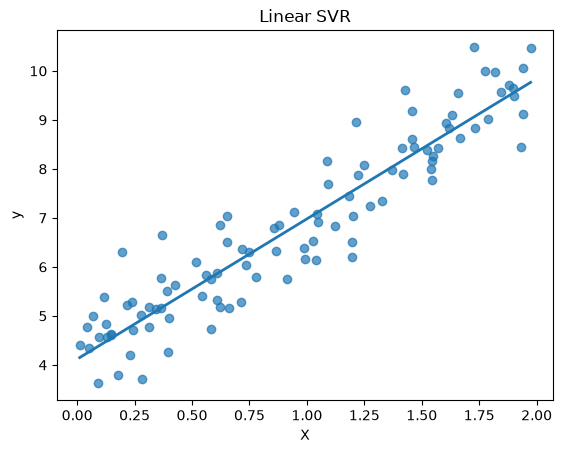

In [16]:
rng = np.random.RandomState(42)
X_reg = 2 * rng.rand(100, 1)
y_reg = 4 + 3 * X_reg[:, 0] + rng.randn(100) * 0.7

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear", C=10, epsilon=0.3))
])

svr.fit(X_reg, y_reg)
pred_reg = svr.predict(X_reg)

print("RMSE:", mean_squared_error(y_reg, pred_reg) ** 0.5)

order = np.argsort(X_reg[:, 0])
plt.scatter(X_reg, y_reg, alpha=0.7)
plt.plot(X_reg[order], pred_reg[order], linewidth=2)
plt.title("Linear SVR")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## 12. Scaling and practical limitations

SVMs are sensitive to feature scales because they depend on distances and/or dot products.

Use:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(...))
])
```

### Dataset size

Kernel SVMs are often excellent for **small-to-medium datasets**, but can become impractical as the number of samples becomes very large.

For very large datasets, consider scalable linear/online methods.

## 13. When should you use an SVM?

### Good candidates
- Small or medium-sized datasets.
- High-dimensional feature spaces.
- Problems where a maximum-margin boundary is useful.
- Text classification with a linear SVM.
- Nonlinear boundaries where RBF/polynomial kernels are appropriate.

### Be cautious when
- The dataset is extremely large.
- You need naturally calibrated probabilities.
- Training speed is critical.
- Interpretability is more important than predictive performance.